# 01 · SBOM Risk & Dependency Blast Radius

            A reproducible investigation of a **synthetic dependency takeover** using CycloneDX data, evidence rules, and graph reachability.

## tl;dr

            The compromised fixture is **BLOCK** at **100/100**. The scanner found **15 findings** across **7 components**, including **4 critical** and **7 high-severity findings**. The widest single finding can affect **6 synthetic services**.

## Context & Methods

            We parse one versioned CycloneDX fixture, run the repository's deterministic evidence rules, and separately examine dependency reachability. Rules establish *what happened*; the learned model only ranks the combined release risk.

            ### Key Assumptions

            - Package reputation, advisory, and reachability fields beginning with `guardian:` are synthetic labels.
            - A graph edge means “depends on,” not proof that a vulnerable function is called.
            - Blast radius is a prioritization aid, not an exploitability claim.

## Data

Load the versioned SBOM and checked-in scan output so every number is traceable.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or a child directory")
sys.path.insert(0, str(ROOT / "src"))

ORANGE = "#f97316"
GOLD = "#f59e0b"
BLUE = "#2563eb"
INK = "#172033"
GRID = "#e5e7eb"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
})

In [2]:
from supplychain_guardian.graph import dependency_adjacency, impacted_nodes
from supplychain_guardian.parsers import load_document
from supplychain_guardian.scanner import scan_bundle

sbom_path = ROOT / "data" / "sboms" / "compromised.cdx.json"
workflow_path = ROOT / "data" / "workflows" / "compromised.yml"
attestation_path = ROOT / "data" / "attestations" / "tampered.json"
sbom, _ = load_document(sbom_path)
report = scan_bundle(sbom_path, workflow_path, attestation_path, scenario="compromised")

summary = pd.DataFrame([report.to_dict()["summary"]]).T.rename(columns={0: "value"})
summary

,value
risk_score,100
decision,BLOCK
model_probability,0.999999
components_scanned,7
workflow_steps_scanned,4
artifact_name,dist/guardian_app-1.4.3-rc1-py3-none-any.whl
finding_count,15
severity_counts,"{'critical': 4, 'high': 7, 'medium': 4, 'low':..."
max_blast_radius,6


In [3]:
assert sbom["bomFormat"] == "CycloneDX"
assert len(sbom["components"]) == report.components_scanned
assert report.data_classification == "synthetic-demo"
print(f"Validated {report.components_scanned} components and {len(sbom['dependencies'])} dependency records.")

Validated 7 components and 7 dependency records.


## Results

First compare severity counts, then inspect which evidence has the largest reachable footprint.

<notebook>:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


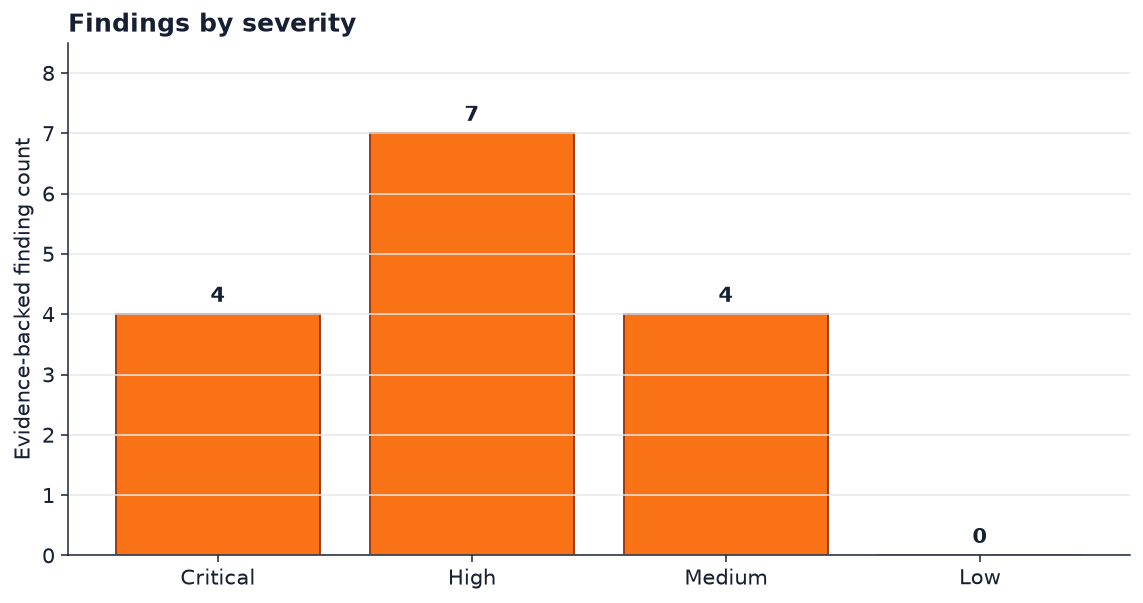

In [4]:
severity_order = ["critical", "high", "medium", "low"]
values = [report.severity_counts[name] for name in severity_order]
fig, ax = plt.subplots(figsize=(8.6, 4.6))
bars = ax.bar([name.title() for name in severity_order], values, color=ORANGE, edgecolor="#9a3412")
ax.bar_label(bars, padding=4, fontweight="bold")
ax.set_title("Findings by severity", loc="left", fontweight="bold")
ax.set_ylabel("Evidence-backed finding count")
ax.set_ylim(0, max(values) + 1.5)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

<notebook>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


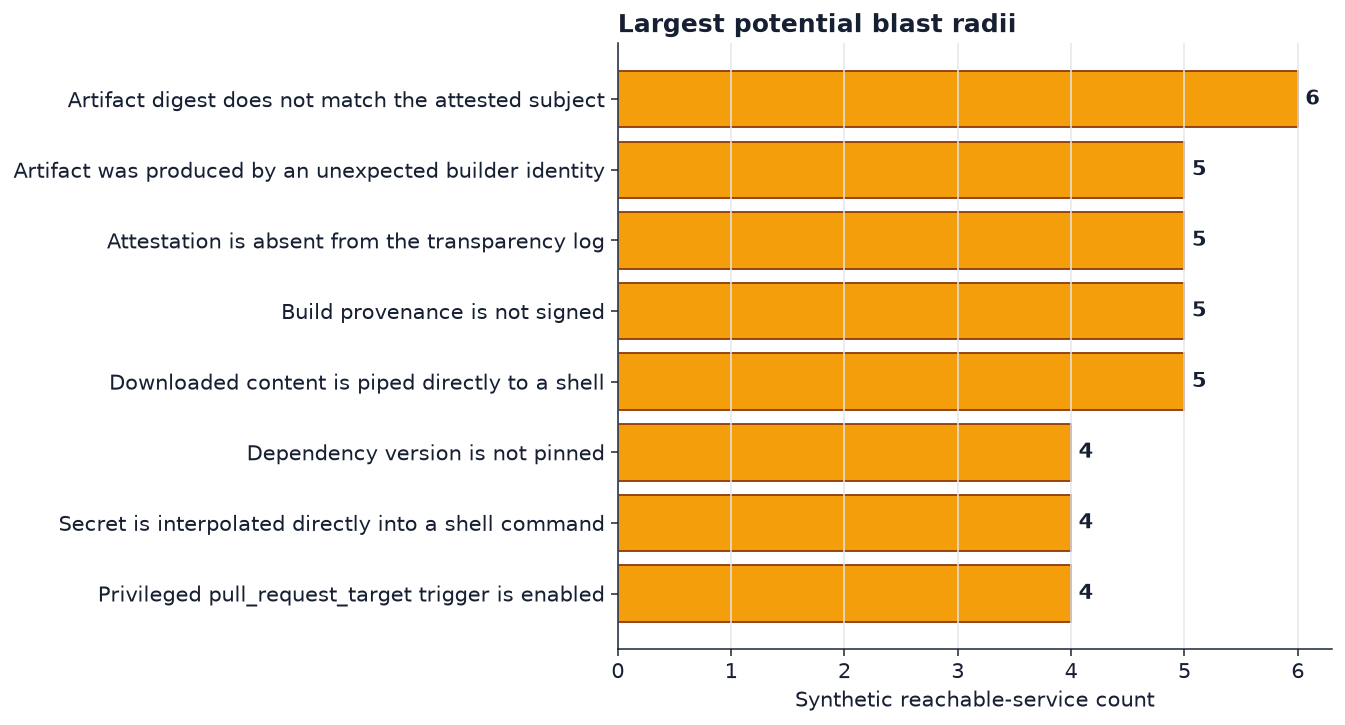

In [5]:
finding_frame = pd.DataFrame([
    {
        "finding": item.title,
        "severity": item.severity,
        "category": item.category,
        "blast_radius": item.blast_radius,
        "subject": item.subject,
    }
    for item in report.findings
]).sort_values(["blast_radius", "severity"], ascending=[True, True])

top_findings = finding_frame.tail(8)
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(top_findings["finding"], top_findings["blast_radius"], color=GOLD, edgecolor="#92400e")
ax.bar_label(bars, padding=4, fontweight="bold")
ax.set_title("Largest potential blast radii", loc="left", fontweight="bold")
ax.set_xlabel("Synthetic reachable-service count")
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

pkg:pypi/build-helper@latest can affect ['gateway', 'guardian-app', 'pkg:pypi/build-helper@latest', 'trainer']
pkg:pypi/reqeusts@99.0.0 can affect ['agent-runtime', 'gateway', 'guardian-app', 'pkg:pypi/reqeusts@99.0.0', 'trainer']


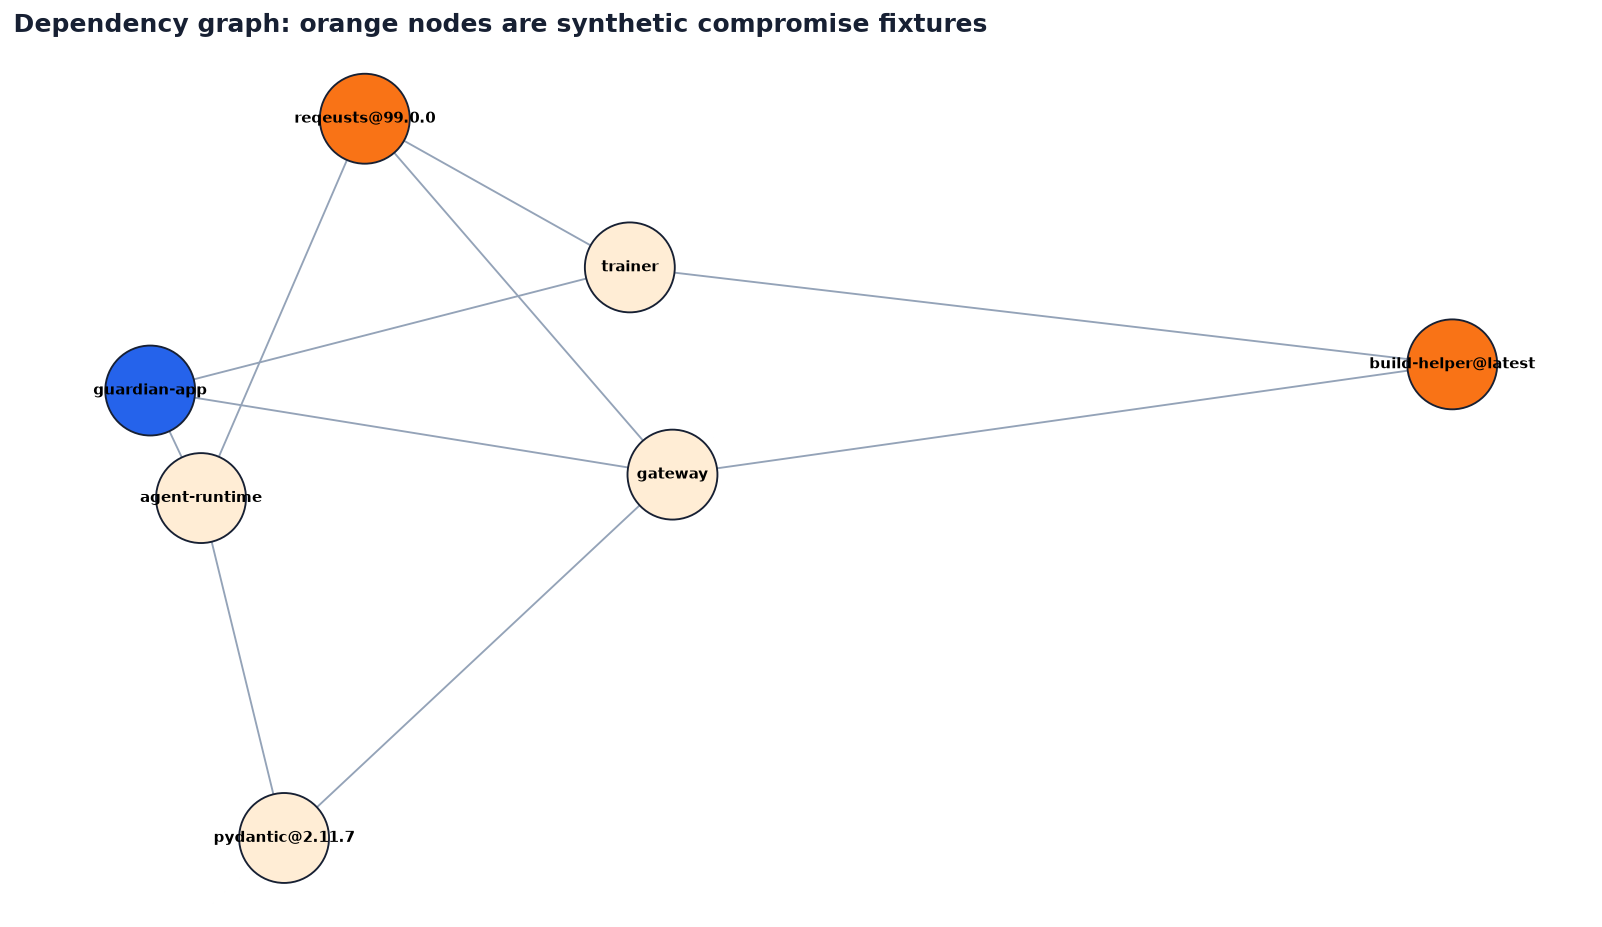

In [6]:
import networkx as nx

graph_map = dependency_adjacency(sbom)
graph = nx.DiGraph()
for parent, children in graph_map.items():
    for child in children:
        graph.add_edge(parent, child)

compromised_nodes = {"pkg:pypi/reqeusts@99.0.0", "pkg:pypi/build-helper@latest"}
positions = nx.spring_layout(graph, seed=11, k=0.9)
colors = [ORANGE if node in compromised_nodes else BLUE if node == "guardian-app" else "#ffedd5" for node in graph.nodes]
labels = {node: node.replace("pkg:pypi/", "").replace("pkg:generic/", "") for node in graph.nodes}

fig, ax = plt.subplots(figsize=(12, 7))
nx.draw_networkx_edges(graph, positions, ax=ax, edge_color="#94a3b8", arrows=True, arrowsize=16)
nx.draw_networkx_nodes(graph, positions, ax=ax, node_color=colors, edgecolors=INK, node_size=2300)
nx.draw_networkx_labels(graph, positions, labels=labels, ax=ax, font_size=8, font_weight="bold")
ax.set_title("Dependency graph: orange nodes are synthetic compromise fixtures", loc="left", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

for node in sorted(compromised_nodes):
    print(node, "can affect", impacted_nodes(graph_map, node))

## Takeaways

            1. **Integrity dominates the decision.** The mismatched artifact digest and unsafe execution path make this a block even before finer ranking.
            2. **Reachability changes priority.** `dist/guardian_app-1.4.3-rc1-py3-none-any.whl` has the largest synthetic reach at **6 services**.
            3. **The graph does not prove exploitation.** Production use should combine SBOM identity, vulnerability status, runtime reachability, and verified provenance.